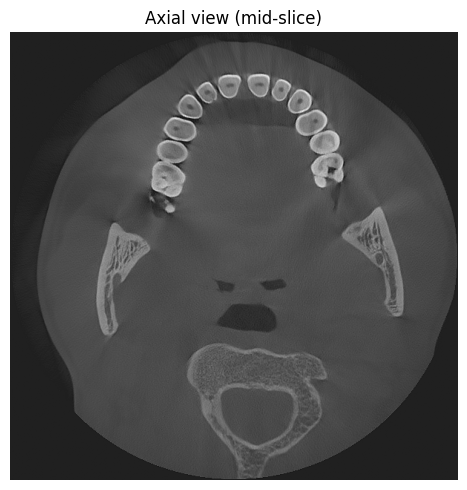

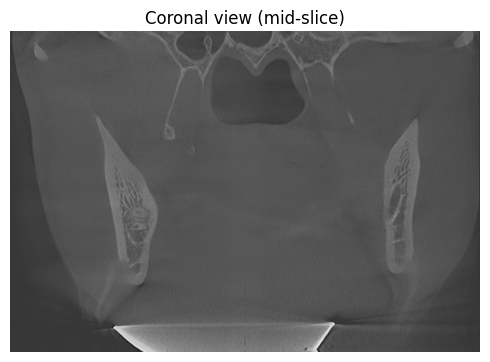

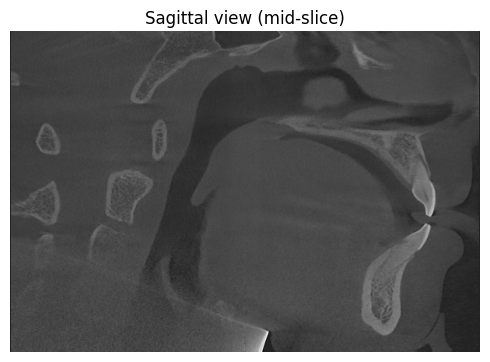

In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image
# Paths (Windows-friendly)
cbct_path = r"assets\cbctImg\003_cbct.nii"
output_dir = r"assets\cbctDifferentView"

# Ensure output folder exists
os.makedirs(output_dir, exist_ok=True)

# Load NIfTI
img = nib.load(cbct_path)
data = img.get_fdata()

# Use mid-slices for standard views
z_mid = data.shape[2] // 2  # axial (Z)
y_mid = data.shape[1] // 2  # coronal (Y)
x_mid = data.shape[0] // 2  # sagittal (X)

axial = data[:, :, z_mid]
coronal = data[:, y_mid, :]
sagittal = data[x_mid, :, :]

# Plot and save
views = {
    "axial": axial,
    "coronal": coronal,
    "sagittal": sagittal
}

for name, slice_2d in views.items():
    plt.figure(figsize=(5, 5))
    plt.imshow(np.rot90(slice_2d), cmap="gray")
    plt.title(f"{name.capitalize()} view (mid-slice)")
    plt.axis("off")
    plt.tight_layout()
    out_path = os.path.join(output_dir, f"{name}.png")
    plt.savefig(out_path, dpi=200, bbox_inches="tight", pad_inches=0)
    plt.show()

In [3]:
import os
import nibabel as nib
import numpy as np
from PIL import Image

# 1. Define paths
output_folder = r'assets\axialViewSlices'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 2. Load the CBCT image
# Assuming 'cbct_path' is your predefined variable
img = nib.load(cbct_path)
data = img.get_fdata()

# 3. Extract Axial Slices
# In medical imaging (RAS/LPS orientation), the 3rd axis (index 2) 
# usually represents the axial plane (superior to inferior).
num_slices = data.shape[2]

print(f"Processing {num_slices} axial slices...")

for i in range(num_slices):
    # Extract the 2D slice
    slice_data = data[:, :, i]
    
    # Normalize the data to 0-255 (standard grayscale)
    # This is crucial as CBCT data often uses Hounsfield Units or high bit-depths
    slice_min = np.min(slice_data)
    slice_max = np.max(slice_data)
    
    if slice_max - slice_min != 0:
        normalized_slice = (slice_data - slice_min) / (slice_max - slice_min) * 255
    else:
        normalized_slice = slice_data
        
    # Convert to unsigned 8-bit integer
    img_slice = Image.fromarray(normalized_slice.astype(np.uint8))
    
    # Save the slice
    slice_name = f"axial_slice_{i:03d}.png"
    img_slice.save(os.path.join(output_folder, slice_name))

print(f"Extraction complete. Slices saved to: {output_folder}")

Processing 412 axial slices...
Extraction complete. Slices saved to: assets\axialViewSlices
